# COMP 333 Project

- Matthew Lucas Santiago 40284787
- Darcy McCoy 40234556

## Executivate Summary
Predicting the outcome of a chess game before it is played remains a difficult problem, even though it is one of the most studied strategy games. This project analyses a large dataset of online chess games played on Lichess, an open-source chess platform. It aims to investigate the following research questions:
1. Can a model be trained to accurately predict the result of an online chess game based on factors like elo and rating?

2. Can we categorize chess games into different difficulty levels based on time control, rating difference, and opening type?

The dataset includes millions of games and contains information such as play elo ratings, time controls, and opening codes. The data was then cleaned and meaningful features were derived from the clean data. These features were selected using both filter and embedded methods, then passed to four machine learning models: Logistic Regression, Random Forest, XGBoost, and LightGBM.

Random Forest achieved the best overall performance with an accuracy of 63.71% and an F1-Macro score of 0.4324. Although all the models performed meaningfully above random guessing, they still struggled to predict games due to several limitations including class imbalance for drawn games, computational power, and the outcome of chess being more influenced by in-game stats rather than pre-game stats. Future work could include in-game information like move quality scores paired with greater computational resources.


## Data Retrieval

The data was obtained here: [https://www.kaggle.com/datasets/rohinpinisetti/chessfeb2016?select=Feb2016_chunk2.csv](https://www.kaggle.com/datasets/rohinpinisetti/chessfeb2016?select=Feb2016_chunk2.csv)

To run our scripts:
1. Download the csv (ensure it is only chunk 2)
2. Unzip the data
3. Put the csv in the same directory as the jupyter file as shown here:

    ```bash
    ├── project.ipynb
    └── chess-data.csv
    ```

## Division of Labour
The labour for this assignment was split equally between the two of us.

## Table of Contents
- Phase 1: Data Acquisition & Baseline
  - Data Wrangling / Cleaning
  - EDA and Baseline Model
  - Research Questions
- Phase 2: Advanced Modeling
  - Feature Engineering
  - Advanced Supervised Learning
  - Unsupervised Learning
- Ethical Considerations

## Data Wrangling / Cleaning
Note that the dataset includes different event types (Blitz, Bullet, Classical games and tournaments) which provides for a spread of games across time formats, skill level and competiveness.

Initially, the number of missing values, duplicate rows, and outliers were found. In the columns 'WhiteElo', 'BlackElo', 'WhiteRatingDiff', and 'BlackRatingDiff', the percent of missing values were 0.000041, 0.00204, 0.081333 and 0.081333 respectively. Since these missing values represent a very small percentage, the rows were simply removed.

On the other hand, for the columns 'WhiteTitle' and 'BlackTitle', 99.47% of the values were missing, so these columns were removed entirely. This large amount of missing data can be explained by the fact that only the very top players on Lichess are given titles.

Next, the number of duplicate rows were identified. Since only a total of 6 rows were found, they were removed to ensure each row represents a unique chess game.

Additionally, outliers were analyzed from the quantDDA. Around 6000 outliers were found in WhiteElo and BlackElo. Although these outliers  were detected, they represent extreme but valid ratings from high-level or low-level players. These outliers were verified as real players, see [this lichess post](https://lichess.org/forum/general-chess-discussion/what-is-the-highest-rating-you-can-rating-you-can-reach-on-lichess) for a discussion of the highest possible elo. Since these values are meaningful and represent a minimal percentage, they were preserved.

Finally, to make the 'Result' column more meaningful and clear, a 'Winner' column was added based on the 'Result' column with possible values: 'Black', 'White', and 'Draw'. A separate 'Encodedwinner' column was added for future use in the ML.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,roc_auc_score, roc_curve, auc)
import warnings
warnings.filterwarnings("ignore")


def _as_row(series, label):
    # Convert a Series to a single-row DataFrame with the given index label
    return series.to_frame().T.rename(index={series.name if series.name is not None else 0: label})


def _missing_entries(df, numeric_cols):
    try:
        row = df.isna().sum()[numeric_cols]
        return _as_row(row, "missing_entries")
    except Exception as e:
        print(f"[quantDDA] missing-entries computation failed: {e}")
        return pd.DataFrame(index=["missing_entries"], columns=numeric_cols)


def _num_observations(desc, missing_row):
    try:
        combined = desc.loc["count"] + missing_row.iloc[0]
        return _as_row(combined, "num_of_observations")
    except Exception as e:
        print(f"[quantDDA] observation-count computation failed: {e}")
        return pd.DataFrame(index=["num_of_observations"], columns=desc.columns)


def _unique_entries(df, numeric_cols):
    try:
        row = df.nunique()[numeric_cols]
        return _as_row(row, "unique_entries")
    except Exception as e:
        print(f"[quantDDA] unique-entry computation failed: {e}")
        return pd.DataFrame(index=["unique_entries"], columns=numeric_cols)


def _outliers_zscore(df, numeric_cols, threshold=3):
    try:
        z = pd.DataFrame(np.abs(stats.zscore(df[numeric_cols])), columns=numeric_cols)
        row = (z > threshold).sum()
        return _as_row(row, "num_of_outliers")
    except Exception as e:
        print(f"[quantDDA] z-score outlier computation failed: {e}")
        return pd.DataFrame(index=["num_of_outliers"], columns=numeric_cols)


def _extreme_counts(df, numeric_cols, quantile, compare):
    # Count values above/below a percentile threshold per column
    try:
        thresholds = df.quantile(quantile, numeric_only=True)
        row = compare(df[numeric_cols], thresholds).sum()
        label = "values_in_top_one_percent" if compare.__name__ == "gt" else "values_in_bottom_one_percent"
        return _as_row(row, label)
    except Exception as e:
        print(f"[quantDDA] extreme-count computation ({quantile}) failed: {e}")
        return pd.DataFrame()


def _mode_row(df, numeric_cols):
    try:
        m = df.mode()[numeric_cols].iloc[0]
        return _as_row(m, "mode")
    except Exception as e:
        print(f"[quantDDA] mode computation failed: {e}")
        return pd.DataFrame(index=["mode"], columns=numeric_cols)


def _shape_row(df, numeric_cols, func, label):
    try:
        row = func(df[numeric_cols])
        return _as_row(row, label)
    except Exception as e:
        print(f"[quantDDA] {label} computation failed: {e}")
        return pd.DataFrame(index=[label], columns=numeric_cols)


def quantDDA(df):
    # Quantitative data description: summary, missingness, outliers, shape stats
    if not isinstance(df, pd.DataFrame) or df.empty:
        raise ValueError("quantDDA requires a non-empty pandas DataFrame")

    try:
        dataframe = df.describe()
    except Exception as e:
        raise RuntimeError(f"describe() failed: {e}") from e

    numeric_cols = dataframe.columns
    import operator

    rows = [
        dataframe,
        _missing_entries(df, numeric_cols),
    ]
    rows.append(_num_observations(dataframe, rows[-1]))
    rows.append(_unique_entries(df, numeric_cols))
    rows.append(_outliers_zscore(df, numeric_cols))
    rows.append(_extreme_counts(df, numeric_cols, 0.99, operator.gt))
    rows.append(_extreme_counts(df, numeric_cols, 0.01, operator.lt))
    rows.append(_mode_row(df, numeric_cols))
    rows.append(_shape_row(df, numeric_cols, lambda x: x.skew(), "skewness"))
    rows.append(_shape_row(df, numeric_cols, lambda x: x.kurtosis(), "kurtosis"))

    return pd.concat(rows)


In [2]:
MAX_UNIQUE_CATEGORIES = 8
MAX_LABEL_LENGTH = 16


def _is_object_like(series):
    return series.dtype == "object" or str(series.dtype) == "category"


def _unique_count(series):
    try:
        return int(series.nunique(dropna=True))
    except Exception:
        return None


def _show_cell_message(ax, msg):
    ax.text(0.5, 0.5, msg, ha="center", va="center",
            transform=ax.transAxes, fontsize=9, color="gray")
    ax.set_xticks([])
    ax.set_yticks([])


def _top_n_order(series, n):
    return list(series.value_counts(dropna=True).head(n).index)


def _truncate(text, max_len=MAX_LABEL_LENGTH):
    s = str(text)
    return s if len(s) <= max_len else s[: max_len - 1] + "…"


def _tidy_xticklabels(ax, rotate=True):
    # Truncate long category names and rotate so they don't overlap or overflow the cell
    labels = [_truncate(t.get_text()) for t in ax.get_xticklabels()]
    ax.set_xticklabels(labels, rotation=45 if rotate else 0, ha="right" if rotate else "center")


def _tidy_yticklabels(ax):
    labels = [_truncate(t.get_text()) for t in ax.get_yticklabels()]
    ax.set_yticklabels(labels)


def _plot_diagonal_cell(ax, df, col):
    # Histogram for numeric, count plot for categorical (top-N when many categories)
    series = df[col]
    if pd.api.types.is_numeric_dtype(series):
        sns.histplot(series, ax=ax)
        return
    if not _is_object_like(series):
        _show_cell_message(ax, f"'{col}': dtype {series.dtype}\nnot plottable on diagonal")
        return

    n_unique = _unique_count(series)
    non_null = series.dropna()
    if n_unique is None:
        _show_cell_message(ax, f"'{col}': could not count unique values")
        return
    if len(non_null) > 0 and n_unique == len(non_null):
        _show_cell_message(ax, f"'{col}': every value unique\n({n_unique} rows, identifier-like)")
        return
    if n_unique > MAX_UNIQUE_CATEGORIES:
        order = _top_n_order(series, MAX_UNIQUE_CATEGORIES)
        sns.countplot(x=series[series.isin(order)], order=order, ax=ax)
        ax.set_title(f"Top {MAX_UNIQUE_CATEGORIES} of {n_unique} categories", fontsize=9)
    else:
        sns.countplot(x=series, ax=ax)
    _tidy_xticklabels(ax)


def _plot_cat_vs_numeric(ax, cat_series, num_series, cat_name, horizontal=False):
    # Boxplot of numeric across categorical, restricted to top-N categories when high-cardinality
    n_unique = _unique_count(cat_series)
    non_null = cat_series.dropna()
    if n_unique is None:
        _show_cell_message(ax, f"'{cat_name}': could not count unique values")
        return
    if len(non_null) > 0 and n_unique == len(non_null):
        _show_cell_message(ax, f"'{cat_name}': every value unique\n({n_unique} rows, identifier-like)")
        return
    if n_unique > MAX_UNIQUE_CATEGORIES:
        order = _top_n_order(cat_series, MAX_UNIQUE_CATEGORIES)
        mask = cat_series.isin(order)
        cat_plot, num_plot = cat_series[mask], num_series[mask]
        if horizontal:
            sns.boxplot(x=num_plot, y=cat_plot, order=order, ax=ax)
        else:
            sns.boxplot(x=cat_plot, y=num_plot, order=order, ax=ax)
        ax.set_title(f"Top {MAX_UNIQUE_CATEGORIES} of {n_unique} categories", fontsize=9)
    else:
        if horizontal:
            sns.boxplot(x=num_series, y=cat_series, ax=ax)
        else:
            sns.boxplot(x=cat_series, y=num_series, ax=ax)
    if horizontal:
        _tidy_yticklabels(ax)
    else:
        _tidy_xticklabels(ax)


def _plot_offdiagonal_cell(ax, df, col_y, col_x):
    # Pick a plot type based on the dtypes of the two columns
    sy, sx = df[col_y], df[col_x]
    y_numeric = pd.api.types.is_numeric_dtype(sy)
    x_numeric = pd.api.types.is_numeric_dtype(sx)
    x_object = _is_object_like(sx)
    y_object = _is_object_like(sy)
    x_datetime = pd.api.types.is_datetime64_any_dtype(sx)

    if y_numeric and x_numeric:
        sns.scatterplot(x=sx, y=sy, ax=ax)
        return
    if x_datetime and y_numeric:
        sns.lineplot(x=sx, y=sy, ax=ax)
        return
    if y_numeric and x_object:
        _plot_cat_vs_numeric(ax, sx, sy, col_x)
        return
    if y_object and x_numeric:
        _plot_cat_vs_numeric(ax, sy, sx, col_y, horizontal=True)
        return
    if y_object and x_object:
        nx, ny = _unique_count(sx), _unique_count(sy)
        _show_cell_message(
            ax,
            f"Two categorical columns:\n{col_y} ({ny} unique) vs\n{col_x} ({nx} unique)\nno bivariate plot",
        )
        return
    _show_cell_message(
        ax,
        f"No plot for\n{col_y} ({sy.dtype}) vs\n{col_x} ({sx.dtype})",
    )


def _format_axis_labels(ax, row, col, col1, col2):
    if row == col:
        ax.set_xlabel(col2)
    else:
        ax.set_xticklabels([])
        ax.set_xlabel("")

    if col == row:
        ax.set_ylabel(col1)
    else:
        ax.set_yticklabels([])
        ax.set_ylabel("")


def _plot_missing_heatmap(df):
    try:
        plt.figure(figsize=(10, 6))
        sns.heatmap(df.isnull(), cbar=False)
        plt.title("Heatmap of Missing Values")
        plt.show()
    except Exception as e:
        print(f"[vizDDA] missing-value heatmap failed: {e}")


def vizDDA(df):
    # Visual DDA: upper-triangular grid of uni/bivariate plots plus missing-value heatmap
    if not isinstance(df, pd.DataFrame) or df.empty:
        raise ValueError("vizDDA requires a non-empty pandas DataFrame")

    cols = df.columns
    n = len(cols)
    fig, axes = plt.subplots(n, n, figsize=(4 * n, 4 * n))

    for i, col1 in enumerate(cols):
        for j, col2 in enumerate(cols):
            ax = axes[i, j]
            if j < i:
                ax.set_visible(False)
                continue

            _format_axis_labels(ax, i, j, col1, col2)

            try:
                if i == j:
                    _plot_diagonal_cell(ax, df, col1)
                else:
                    _plot_offdiagonal_cell(ax, df, col1, col2)
            except Exception as e:
                print(f"[vizDDA] cell ({col1}, {col2}) failed: {e}")
                _show_cell_message(ax, f"Plot error:\n{e}")

    fig.suptitle("Grid of plots")
    plt.tight_layout()
    plt.show()

    _plot_missing_heatmap(df)


In [3]:
def load_chess_data(path="chess-data.csv"):
    # Load the raw Lichess CSV, keeping only the columns we need
    usecols = ["Event", "Result", "WhiteElo", "BlackElo", "TimeControl",
               "WhiteTitle", "BlackTitle", "ECO", "Opening",
               "WhiteRatingDiff", "BlackRatingDiff"]
    try:
        return pd.read_csv(path, usecols=usecols, low_memory=False)
    except FileNotFoundError as e:
        raise FileNotFoundError(f"Could not find dataset at {path}") from e
    except Exception as e:
        raise RuntimeError(f"Failed to load {path}: {e}") from e


def coerce_elo_columns(df, cols=("WhiteElo", "BlackElo")):
    # Force Elo columns to numeric
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df


def report_missing(df):
    try:
        print(df.isna().mean() * 100)
    except Exception as e:
        print(f"[clean] missing-percentage report failed: {e}")


def drop_sparse_columns(df, cols=("WhiteTitle", "BlackTitle")):
    present = [c for c in cols if c in df.columns]
    return df.drop(columns=present)


def drop_duplicates_reporting(df):
    try:
        n = df.duplicated().sum()
        print(f"Number of duplicate rows: {n}")
    except Exception as e:
        print(f"[clean] duplicate count failed: {e}")
    return df.drop_duplicates()


def drop_missing_required(df, required=("WhiteElo", "BlackElo", "WhiteRatingDiff", "BlackRatingDiff")):
    present = [c for c in required if c in df.columns]
    return df.dropna(subset=present)


def add_winner_columns(df):
    # Add human-readable Winner and numeric EncodedWinner target columns
    if "Result" not in df.columns:
        raise KeyError("Result column required to derive Winner")
    df["Winner"] = df["Result"].map({"1-0": "White", "0-1": "Black", "1/2-1/2": "Draw"})
    df["EncodedWinner"] = df["Winner"].map({"White": 0, "Black": 1, "Draw": 2})
    return df


def prepare_chess_df(path="chess-data.csv"):
    # Full load + clean + label pipeline
    df = load_chess_data(path)
    df = coerce_elo_columns(df)
    report_missing(df)
    df = drop_sparse_columns(df)
    df = drop_duplicates_reporting(df)
    df = drop_missing_required(df)
    df = add_winner_columns(df)
    return df


chess_df = prepare_chess_df()
chess_df.head(10)


Event               0.000000
Result              0.000000
WhiteElo            0.000041
BlackElo            0.000204
WhiteRatingDiff     0.081455
BlackRatingDiff     0.081455
WhiteTitle         99.472131
ECO                 0.000000
Opening             0.000000
TimeControl         0.000000
BlackTitle         99.467239
dtype: float64
Number of duplicate rows: 871


,Event,Result,WhiteElo,BlackElo,WhiteRatingDiff,BlackRatingDiff,ECO,Opening,TimeControl,Winner,EncodedWinner
0,Rated Blitz game,0-1,1623.0,1622.0,-10.0,11.0,B12,"Caro-Kann Defense: Advance Variation, Short Va...",180+0,Black,1
1,Rated Bullet tournament https://lichess.org/to...,0-1,1398.0,2134.0,0.0,0.0,C02,French Defense: Advance Variation,60+0,Black,1
2,Rated Blitz game,1-0,1827.0,1880.0,12.0,-13.0,C44,Scotch Game: Scotch Gambit,180+0,White,0
3,Rated Classical game,1-0,1839.0,1811.0,12.0,-10.0,B01,Scandinavian Defense,900+15,White,0
4,Rated Bullet game,1-0,1918.0,1866.0,10.0,-9.0,B32,Sicilian Defense: Open #3,30+0,White,0
5,Rated Bullet tournament https://lichess.org/to...,1-0,2350.0,1698.0,1.0,-1.0,D00,Queen's Pawn Game #2,60+0,White,0
6,Rated Classical game,0-1,1744.0,1885.0,-7.0,7.0,B06,Robatsch (Modern) Defense,600+0,Black,1
7,Rated Blitz game,1-0,1816.0,1619.0,6.0,-6.0,A40,Horwitz Defense,300+3,White,0
8,Rated Bullet game,0-1,1515.0,1905.0,-2.0,3.0,A00,Van Geet Opening,60+0,Black,1
9,Rated Classical game,0-1,1489.0,1694.0,-8.0,9.0,B09,Pirc Defense: Austrian Attack,300+8,Black,1


In [10]:
quantDDA(chess_df)

,WhiteElo,BlackElo,WhiteRatingDiff,BlackRatingDiff,EncodedWinner
count,2.450182e+06,2.450182e+06,2.450182e+06,2.450182e+06,2.450182e+06
mean,1.737377e+03,1.734983e+03,6.208845e-01,-2.796727e-01,5.387400e-01
std,2.817137e+02,2.832005e+02,2.471483e+01,2.450910e+01,5.673526e-01
min,7.310000e+02,7.360000e+02,-6.000000e+02,-6.150000e+02,0.000000e+00
25%,1.543000e+03,1.540000e+03,-9.000000e+00,-1.000000e+01,0.000000e+00
50%,1.734000e+03,1.732000e+03,1.000000e+00,-1.000000e+00,1.000000e+00
75%,1.922000e+03,1.921000e+03,1.000000e+01,9.000000e+00,1.000000e+00
max,2.993000e+03,3.102000e+03,6.820000e+02,6.820000e+02,2.000000e+00
missing_entries,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
num_of_observations,2.450182e+06,2.450182e+06,2.450182e+06,2.450182e+06,2.450182e+06


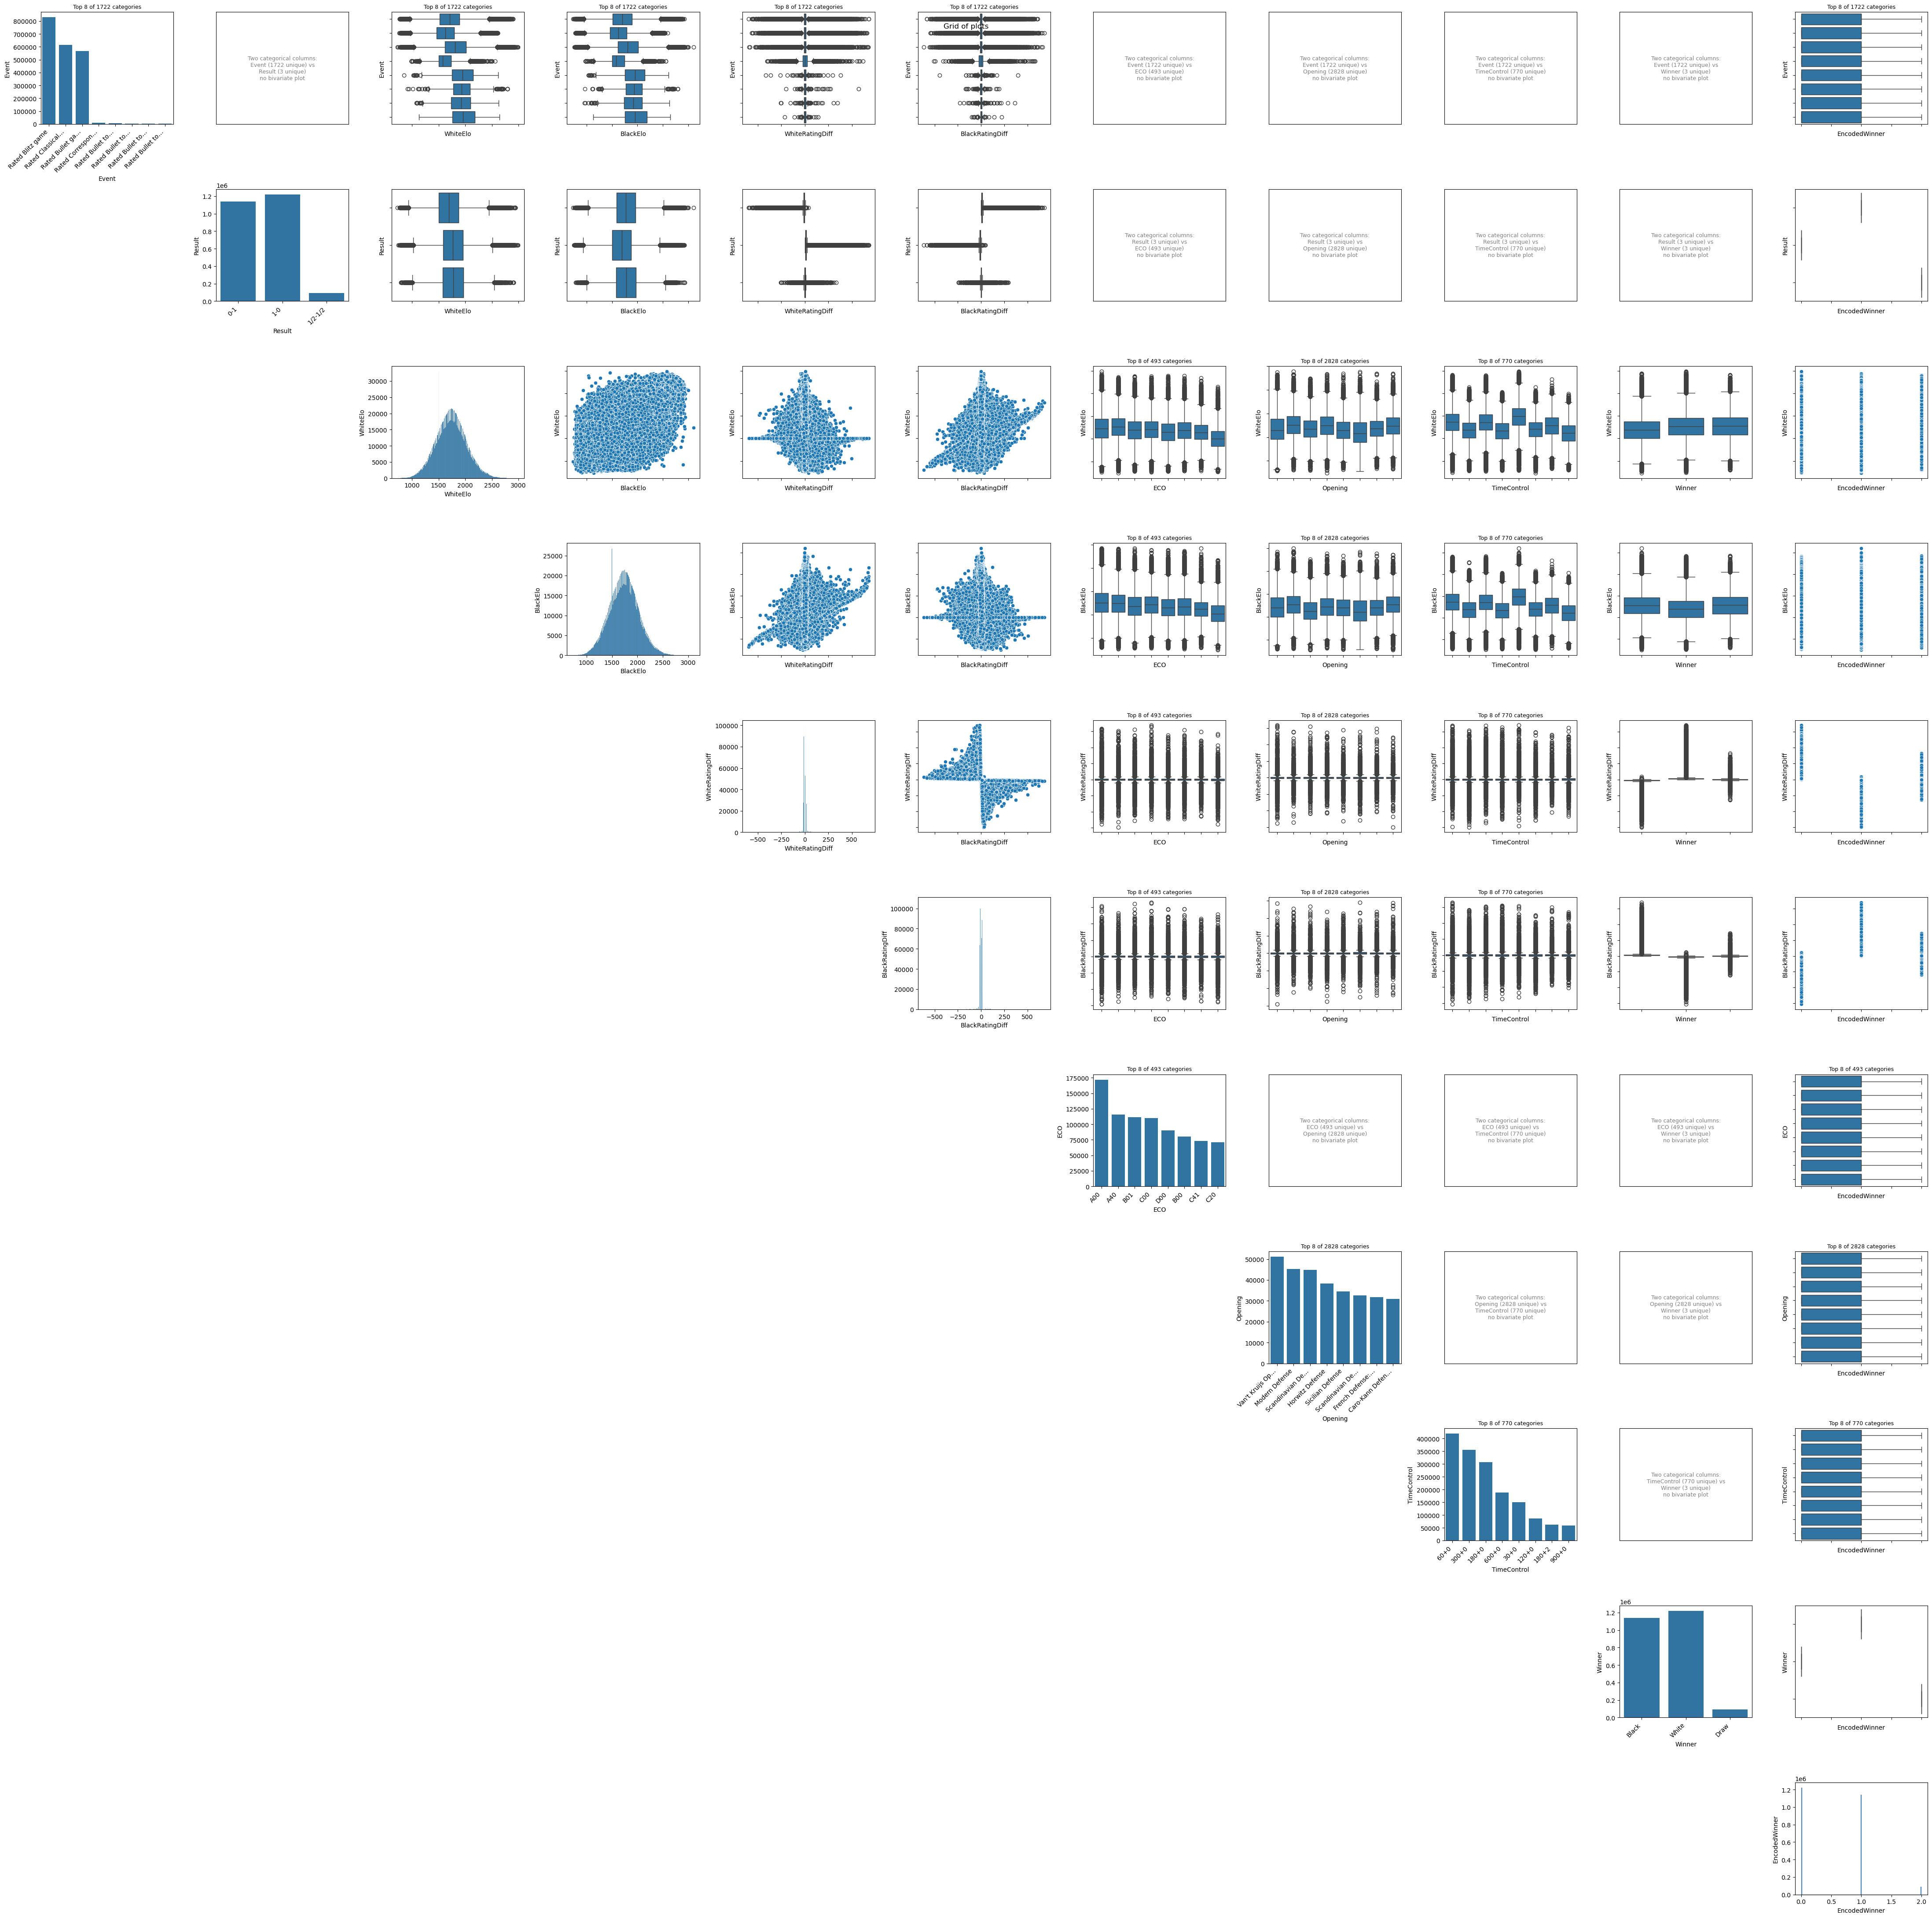

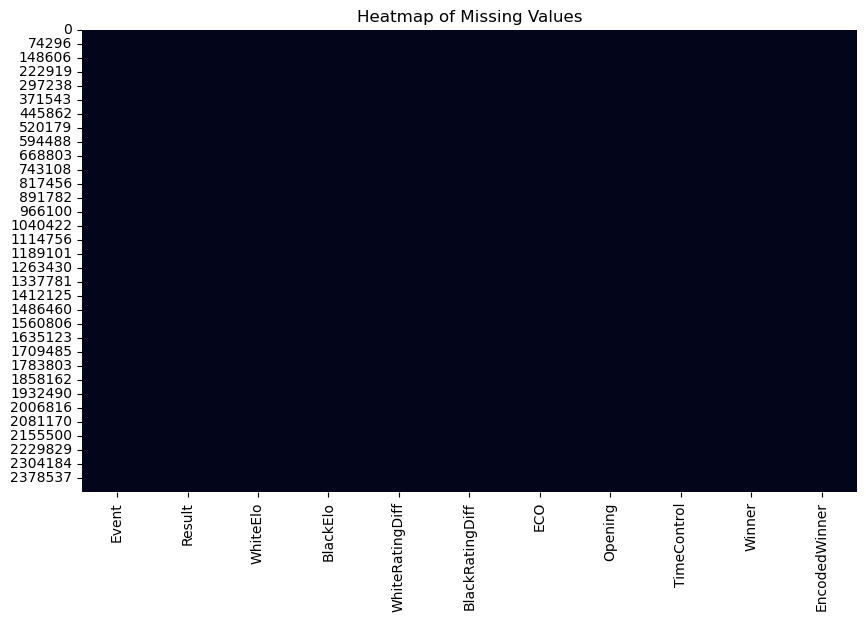

In [11]:
vizDDA(chess_df)

## EDA and Baseline Model
Summary statistics and uni/bivariate visualizations can be found using quantDDA and vizDDA.

Below shows a bivariate visualization between the 'WhiteElo' and 'Winner' columns. The same applies for 'BlackElo' and 'Winner' columns.

The boxplot shows that players with a rating advantage are more likely to win. Also, when there is little to no rating difference, there is a higher chance of the game ending in a draw.

A correlation matrix was computed to analyze the relationship between WhiteElo and BlackElo. The heatmap visualization shows the strength and direction of correlation between these rating difference variables.

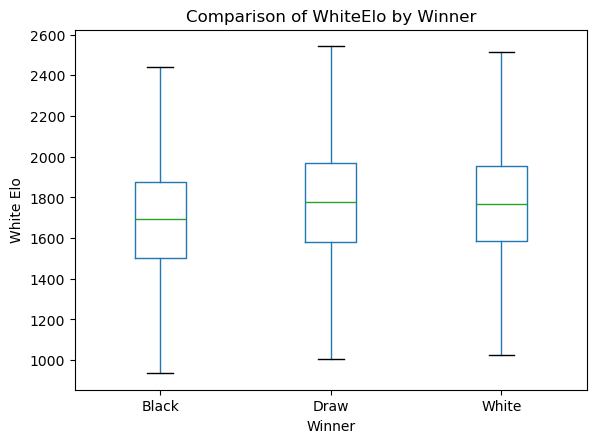

In [4]:
def boxplot_rating_by_winner(df, elo_col, colour_label):
    # Compare an Elo column across Winner categories
    required = {elo_col, "Winner"}
    missing = required - set(df.columns)
    if missing:
        raise KeyError(f"Missing columns for boxplot: {missing}")
    try:
        df.boxplot(column=elo_col, by="Winner", showfliers=False, grid=False)
        plt.title(f"Comparison of {elo_col} by Winner")
        plt.suptitle("")
        plt.xlabel("Winner")
        plt.ylabel(f"{colour_label} Elo")
        plt.show()
    except Exception as e:
        print(f"[boxplot] {elo_col} plot failed: {e}")


boxplot_rating_by_winner(chess_df, "WhiteElo", "White")


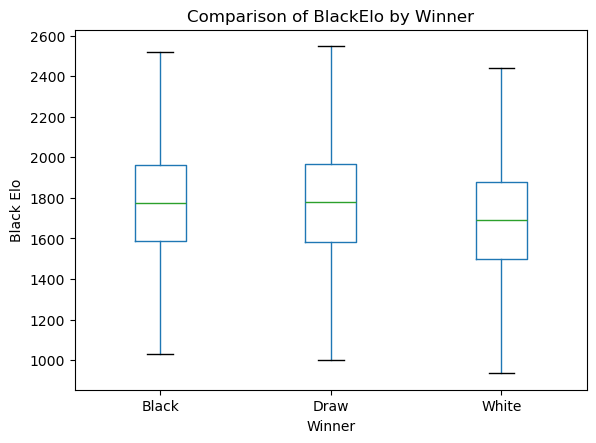

In [5]:
boxplot_rating_by_winner(chess_df, "BlackElo", "Black")


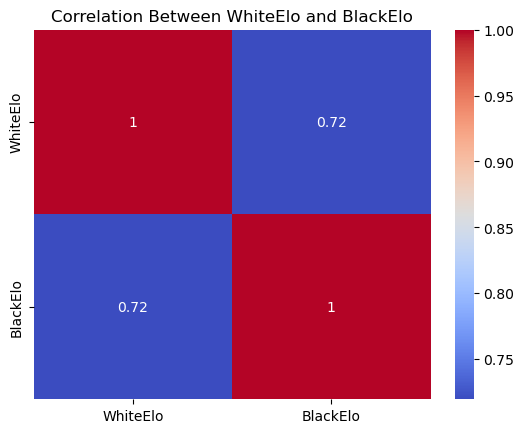

In [6]:
def plot_correlation_heatmap(df, cols, title):
    # Correlation matrix heatmap for the given numeric columns
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise KeyError(f"Missing columns for correlation: {missing}")
    try:
        corr = df[cols].corr()
        sns.heatmap(corr, annot=True, cmap="coolwarm")
        plt.title(title)
        plt.show()
    except Exception as e:
        print(f"[corr] heatmap failed: {e}")


plot_correlation_heatmap(chess_df, ["WhiteElo", "BlackElo"],
                         "Correlation Between WhiteElo and BlackElo")


In [7]:
from sklearn.linear_model import LinearRegression


def add_winner_numeric(df):
    df["WinnerNumeric"] = df["Winner"].map({"White": 1, "Black": 0, "Draw": 0.5})
    return df


def fit_linear_regression(df, feature_cols, target_col):
    # Fit OLS on the chosen features and print coefficients + R^2
    try:
        x = df[feature_cols]
        y = df[target_col]
        model = LinearRegression()
        model.fit(x, y)
        print("Coefficient:", model.coef_)
        print("Intercept:", model.intercept_)
        print("R^2:", model.score(x, y))
        return model
    except Exception as e:
        raise RuntimeError(f"Linear regression fit failed: {e}") from e


chess_df = add_winner_numeric(chess_df)
_ = fit_linear_regression(chess_df, ["WhiteElo"], "WinnerNumeric")


Coefficient: [0.00024603]
Intercept: 0.08884956416830914
R^2: 0.019970057316598178


## Research Questions

Given the previous observations, we came up with the following supervised and unsupervised research questions respectively:

1. Can a model be trained to accurately predict the result of an online chess game based on factors like elo and rating?

2. Can we categorize chess games into different difficulty levels based on time control, rating difference, and opening type?

## Phase 2: Advanced Modeling

### Feature Engineering

In [10]:
def add_elo_features(df):
    # Derive difference/average/ratio/product-style Elo features
    df["EloDiff"] = df["WhiteElo"] - df["BlackElo"]
    df["AvgElo"] = (df["WhiteElo"] + df["BlackElo"]) / 2
    df["EloRatio"] = df["WhiteElo"] / df["BlackElo"]
    df["EloDiff_sq"] = df["EloDiff"] ** 2
    df["WhiteFavoured"] = (df["EloDiff"] > 0).astype(int)
    df["EloProduct"] = df["WhiteElo"] * df["BlackElo"]
    return df


def parse_time_control(tc):
    # Parse strings like "180+0" into (base_seconds, increment_seconds)
    try:
        parts = str(tc).split("+")
        return int(parts[0]), int(parts[1]) if len(parts) > 1 else 0
    except (ValueError, AttributeError):
        return np.nan, np.nan


def tc_category(base):
    # Lichess-style time-control bucket from the base time in seconds
    if pd.isna(base):
        return "Unknown"
    if base < 60:
        return "UltraBullet"
    if base < 180:
        return "Bullet"
    if base < 600:
        return "Blitz"
    if base < 1800:
        return "Rapid"
    return "Classical"


def add_time_control_features(df):
    try:
        parsed = df["TimeControl"].apply(parse_time_control)
    except KeyError as e:
        raise KeyError("TimeControl column required for time-control features") from e
    df["TC_Base"] = [x[0] for x in parsed]
    df["TC_Increment"] = [x[1] for x in parsed]
    df["TC_Total"] = df["TC_Base"] + 40 * df["TC_Increment"]
    df["TC_Category"] = df["TC_Base"].apply(tc_category)
    return df


def add_opening_features(df):
    try:
        df["ECO_Letter"] = df["ECO"].astype(str).str[0]
    except KeyError as e:
        raise KeyError("ECO column required for opening features") from e
    return df


def engineer_features(df):
    df = add_elo_features(df)
    df = add_time_control_features(df)
    df = add_opening_features(df)
    return df


chess_df = engineer_features(chess_df)
new_features = ["EloDiff", "AvgElo", "EloRatio", "EloDiff_sq", "WhiteFavoured",
                "EloProduct", "TC_Base", "TC_Increment", "TC_Total",
                "TC_Category", "ECO_Letter"]


In [11]:
print(chess_df[new_features].describe(include='all').T[['count','mean','std','min','max']].to_string())

                   count           mean            std       min        max
EloDiff        2450182.0       2.394027     211.532856   -1970.0     1858.0
AvgElo         2450182.0    1736.180191     261.908433     805.5     2827.0
EloRatio       2450182.0       1.009765       0.130861  0.318811   2.796905
EloDiff_sq     2450182.0   44751.862227   88885.692081       0.0  3880900.0
WhiteFavoured  2450182.0       0.503093       0.499991       0.0        1.0
EloProduct     2450182.0  3071729.68908  925757.861107  648674.0  7988208.0
TC_Base        2439540.0     309.382941     448.850194       0.0    10800.0
TC_Increment   2439540.0        1.39208        4.77682       0.0      180.0
TC_Total       2439540.0      365.06616     537.282528      30.0    18000.0
TC_Category      2450182            NaN            NaN       NaN        NaN
ECO_Letter       2450182            NaN            NaN       NaN        NaN


In [12]:
def encode_label_columns(df, columns):
    # Fit a LabelEncoder per column; return the encoder dict for later inverse mapping
    encoders = {}
    for src in columns:
        if src not in df.columns:
            raise KeyError(f"Cannot encode missing column: {src}")
        try:
            enc = LabelEncoder()
            df[f"{src}_encoded"] = enc.fit_transform(df[src].astype(str))
            encoders[src] = enc
        except Exception as e:
            raise RuntimeError(f"Encoding {src} failed: {e}") from e
    return encoders


def build_model_frame(df, features, target):
    # Select model columns and drop rows with any NaN in them
    missing = [c for c in features + [target] if c not in df.columns]
    if missing:
        raise KeyError(f"Missing columns for model frame: {missing}")
    return df[features + [target]].dropna()


encoders = encode_label_columns(chess_df, ["TC_Category", "ECO_Letter", "ECO"])
encoder_tc = encoders["TC_Category"]
encoder_eco_letter = encoders["ECO_Letter"]
encoder_eco = encoders["ECO"]

FEATURES = ['WhiteElo', 'BlackElo','EloDiff', 'AvgElo', 'EloRatio','EloDiff_sq', 'WhiteFavoured', 'EloProduct','TC_Base', 'TC_Increment', 'TC_Total','TC_Category_encoded', 'ECO_Letter_encoded', 'ECO_encoded']
TARGET = 'Winner'

model_df = build_model_frame(chess_df, FEATURES, TARGET)
X = model_df[FEATURES]
y = model_df[TARGET]


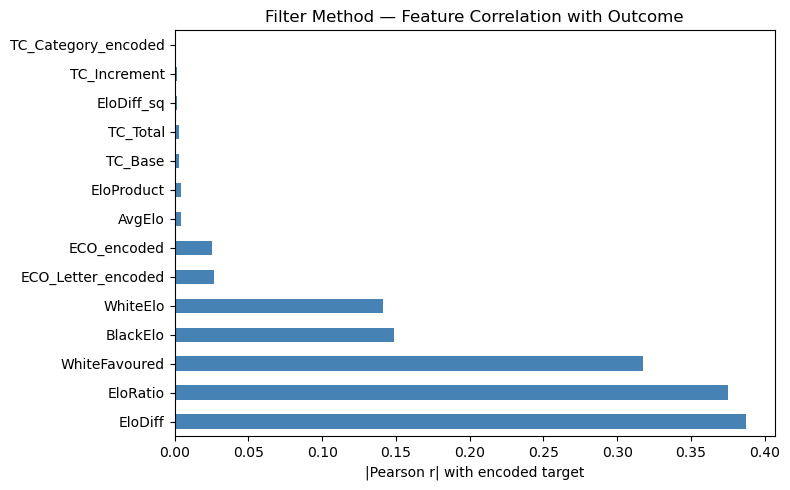

In [13]:
def encode_target(y):
    # Convert string labels to contiguous ints for correlation/regression
    enc = LabelEncoder()
    return enc.fit_transform(y), enc


def filter_method_correlations(X, y_num):
    # |Pearson r| between each feature and the encoded target, sorted descending
    try:
        return X.apply(lambda col: abs(np.corrcoef(col, y_num)[0, 1])).sort_values(ascending=False)
    except Exception as e:
        raise RuntimeError(f"Filter-method correlation failed: {e}") from e


def plot_feature_correlations(corr_series, title, colour="steelblue"):
    plt.figure(figsize=(8, 5))
    corr_series.plot(kind="barh", color=colour)
    plt.xlabel("|Pearson r| with encoded target")
    plt.title(title)
    plt.tight_layout()
    plt.show()


y_num, encoder_label = encode_target(y)
corr_with_target = filter_method_correlations(X, y_num)
plot_feature_correlations(corr_with_target, "Filter Method — Feature Correlation with Outcome")


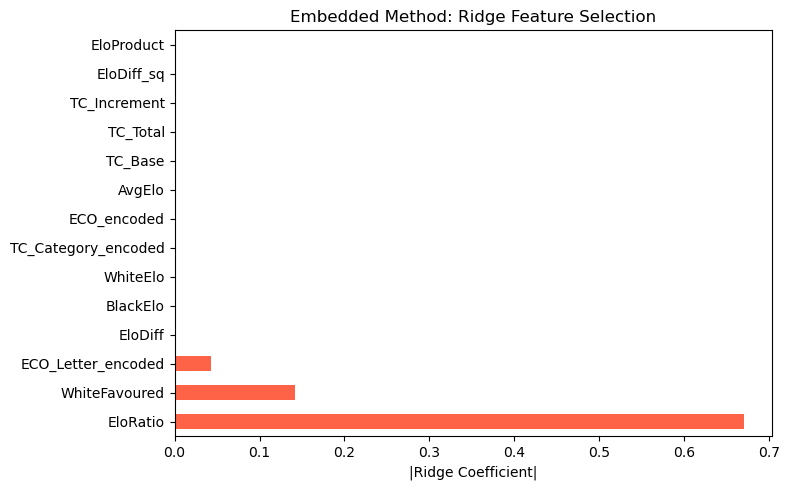


Features below threshold (coefficient < mean=0.0613):
['WhiteElo', 'BlackElo', 'EloDiff', 'AvgElo', 'EloDiff_sq', 'EloProduct', 'TC_Base', 'TC_Increment', 'TC_Total', 'TC_Category_encoded', 'ECO_Letter_encoded', 'ECO_encoded']

Selected features (2):
['EloRatio', 'WhiteFavoured']


In [14]:
from sklearn.linear_model import RidgeCV


def fit_ridge_importances(X, y_num, feature_names, cv=3):
    # Fit RidgeCV and return |coef_| as a sorted Series
    try:
        ridge = RidgeCV(cv=cv)
        ridge.fit(X, y_num)
        return pd.Series(np.abs(ridge.coef_), index=feature_names).sort_values(ascending=False)
    except Exception as e:
        raise RuntimeError(f"RidgeCV fit failed: {e}") from e


def plot_ridge_importances(importances):
    plt.figure(figsize=(8, 5))
    importances.plot(kind="barh", color="tomato")
    plt.xlabel("|Ridge Coefficient|")
    plt.title("Embedded Method: Ridge Feature Selection")
    plt.tight_layout()
    plt.show()


def select_above_mean(importances, all_features):
    # Keep features whose |coef| is at least the mean of all |coef|s
    threshold = importances.mean()
    selected = importances[importances >= threshold].index.tolist()
    dropped = [f for f in all_features if f not in selected]
    print(f"\nFeatures below threshold (coefficient < mean={threshold:.4f}):")
    print(dropped)
    print(f"\nSelected features ({len(selected)}):")
    print(selected)
    return selected


ridge_importances = fit_ridge_importances(X, y_num, FEATURES)
plot_ridge_importances(ridge_importances)
selected_features = select_above_mean(ridge_importances, FEATURES)


### Advanced Supervised Learning

In [15]:
def split_train_val_test(X, y, test_fraction=0.30, random_state=42):
    # 70/15/15 stratified split via two successive train_test_split calls
    try:
        X_train, X_temp, y_train, y_temp = train_test_split(
            X, y, test_size=test_fraction, stratify=y, random_state=random_state
        )
        X_val, X_test, y_val, y_test = train_test_split(
            X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=random_state
        )
        return X_train, X_val, X_test, y_train, y_val, y_test
    except Exception as e:
        raise RuntimeError(f"Train/val/test split failed: {e}") from e


X_selected = model_df[selected_features]
X_train, X_val, X_test, y_train, y_val, y_test = split_train_val_test(X_selected, y)
print(f"\nSplit sizes — train: {len(X_train):,}  val: {len(X_val):,}  test: {len(X_test):,}")



Split sizes — train: 1,707,678  val: 365,931  test: 365,931


In [16]:
def scale_splits(X_train, X_val, X_test):
    # Fit scaler on training data only, apply to val/test
    try:
        scaler = StandardScaler()
        return (scaler.fit_transform(X_train),
                scaler.transform(X_val),
                scaler.transform(X_test),
                scaler)
    except Exception as e:
        raise RuntimeError(f"Feature scaling failed: {e}") from e


X_train_sc, X_val_sc, X_test_sc, scaler = scale_splits(X_train, X_val, X_test)
classes = encoder_label.classes_


In [17]:
def make_cv(n_splits=5, random_state=42):
    return StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)


cv = make_cv()
results = {}


In [18]:
from sklearn.utils import resample


def stratified_sample(X, y, fraction, random_state=42):
    # Sample a stratified fraction of the training data for hyperparameter search
    try:
        return resample(X, y,
                        n_samples=int(len(X) * fraction),
                        random_state=random_state,
                        stratify=y)
    except Exception as e:
        raise RuntimeError(f"Stratified sample (fraction={fraction}) failed: {e}") from e


X_train_sample, y_train_sample = stratified_sample(X_train_sc, y_train, 0.10)


In [19]:
from sklearn.linear_model import LogisticRegression


def train_logistic_regression(X_train, y_train):
    # Baseline balanced multinomial logistic regression
    try:
        lr = LogisticRegression(class_weight='balanced', max_iter=1000,
                                random_state=42, multi_class='multinomial')
        lr.fit(X_train, y_train)
        return lr
    except Exception as e:
        raise RuntimeError(f"Logistic regression training failed: {e}") from e


results['Logistic Regression'] = train_logistic_regression(X_train_sc, y_train)


In [20]:
from sklearn.ensemble import RandomForestClassifier


RF_PARAM_DIST = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2'],
}


def tune_random_forest(X_sample, y_sample, cv, n_iter=10):
    try:
        search = RandomizedSearchCV(
            RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=1),
            param_distributions=RF_PARAM_DIST,
            n_iter=n_iter, cv=cv, scoring='f1_macro',
            random_state=42, n_jobs=2, verbose=1,
        )
        search.fit(X_sample, y_sample)
        return search
    except Exception as e:
        raise RuntimeError(f"Random Forest hyperparameter search failed: {e}") from e


def refit_random_forest(best_params, X, y, fraction=0.20):
    X_large, y_large = stratified_sample(X, y, fraction)
    try:
        model = RandomForestClassifier(**best_params, random_state=42, n_jobs=1)
        model.fit(X_large, y_large)
        return model
    except Exception as e:
        raise RuntimeError(f"Random Forest refit failed: {e}") from e


print(f"Full training set: {X_train_sc.shape}")
print(f"Sample size: {X_train_sample.shape}")
rf_search = tune_random_forest(X_train_sample, y_train_sample, cv)
print(f"Best params: {rf_search.best_params_}")
results['Random Forest'] = refit_random_forest(rf_search.best_params_, X_train_sc, y_train)


Full training set: (1707678, 2)
Sample size: (170767, 2)
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params: {'n_estimators': 50, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_depth': 10}


In [21]:
!pip install xgboost

In [22]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight


XGB_PARAM_DIST = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3],
}


def encode_xgb_targets(y_train, y_val, y_test, y_train_sample):
    # XGBoost needs integer class labels
    enc = LabelEncoder()
    return (enc.fit_transform(y_train),
            enc.transform(y_val),
            enc.transform(y_test),
            enc.transform(y_train_sample),
            enc)


def tune_xgboost(X_sample, y_sample_enc, cv, n_iter=5):
    try:
        weights = compute_sample_weight(class_weight='balanced', y=y_sample_enc)
        search = RandomizedSearchCV(
            XGBClassifier(eval_metric='mlogloss', random_state=42, n_jobs=1, verbosity=0),
            param_distributions=XGB_PARAM_DIST,
            n_iter=n_iter, cv=cv, scoring='f1_macro',
            random_state=42, n_jobs=2, verbose=1,
        )
        search.fit(X_sample, y_sample_enc, sample_weight=weights)
        return search
    except Exception as e:
        raise RuntimeError(f"XGBoost hyperparameter search failed: {e}") from e


y_train_xgb, y_val_xgb, y_test_xgb, y_train_sample_xgb, encoder_xgb = encode_xgb_targets(
    y_train, y_val, y_test, y_train_sample
)
xgb_search = tune_xgboost(X_train_sample, y_train_sample_xgb, cv)
results['XGBoost'] = xgb_search.best_estimator_
print(f"Best params: {xgb_search.best_params_}")


Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best params: {'subsample': 0.7, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 1.0}


In [23]:
!pip install lightgbm

In [24]:
from lightgbm import LGBMClassifier


LGBM_PARAM_DIST = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 63, 127],
    'subsample': [0.7, 0.8, 1.0],
}


def tune_lightgbm(X_sample, y_sample, cv, n_iter=10):
    try:
        search = RandomizedSearchCV(
            LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=2, verbose=-1),
            param_distributions=LGBM_PARAM_DIST,
            n_iter=n_iter, cv=cv, scoring='f1_macro',
            random_state=42, n_jobs=2, verbose=1,
        )
        search.fit(X_sample, y_sample)
        return search
    except Exception as e:
        raise RuntimeError(f"LightGBM hyperparameter search failed: {e}") from e


lgbm_search = tune_lightgbm(X_train_sample, y_train_sample, cv)
results['LightGBM'] = lgbm_search.best_estimator_
print(f"Best params: {lgbm_search.best_params_}")


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params: {'subsample': 0.8, 'num_leaves': 127, 'n_estimators': 100, 'max_depth': 20, 'learning_rate': 0.1}


In [25]:
from sklearn.metrics import accuracy_score, f1_score


def _predict(model, X, xgb_mode):
    # XGBoost returns integer-encoded labels; map them back to strings
    y_predicted = model.predict(X)
    if xgb_mode:
        y_predicted = encoder_xgb.inverse_transform(y_predicted)
    return y_predicted, model.predict_proba(X)


def _compute_metrics(y_true, y_predicted, y_probability):
    return {
        'Accuracy': accuracy_score(y_true, y_predicted),
        'F1-Macro': f1_score(y_true, y_predicted, average='macro'),
        'F1-Weighted': f1_score(y_true, y_predicted, average='weighted'),
        'ROC-AUC (OvR)': roc_auc_score(
            pd.get_dummies(y_true, dtype=float), y_probability,
            average='macro', multi_class='ovr',
        ),
    }


def evaluate(name, model, X, y_true, xgb_mode=False):
    # Score a fitted model on (X, y_true) and print a classification report
    try:
        y_predicted, y_probability = _predict(model, X, xgb_mode)
        metrics = _compute_metrics(y_true, y_predicted, y_probability)
        print(f"\n{name}")
        print(classification_report(y_true, y_predicted, target_names=sorted(y_true.unique())))
        return {'Model': name, **metrics, '_pred': y_predicted, '_proba': y_probability}
    except Exception as e:
        print(f"[evaluate] {name} failed: {e}")
        return {'Model': name, 'Accuracy': np.nan, 'F1-Macro': np.nan,
                'F1-Weighted': np.nan, 'ROC-AUC (OvR)': np.nan,
                '_pred': np.array([]), '_proba': np.array([])}


In [26]:
def evaluate_all(results_map, X, y_true):
    # Run evaluate() on every fitted model, keeping predictions for later plots
    metrics_list = []
    predicted_store = {}
    for name, model in results_map.items():
        res = evaluate(name, model, X, y_true, xgb_mode=(name == 'XGBoost'))
        predicted_store[name] = res
        metrics_list.append({k: v for k, v in res.items() if not k.startswith('_')})
    return metrics_list, predicted_store


metrics_list, predicted_store = evaluate_all(results, X_test_sc, y_test)



Logistic Regression
              precision    recall  f1-score   support

       Black       0.65      0.58      0.61    170286
        Draw       0.04      0.23      0.07     13401
       White       0.69      0.55      0.61    182244

    accuracy                           0.55    365931
   macro avg       0.46      0.45      0.43    365931
weighted avg       0.65      0.55      0.59    365931


Random Forest
              precision    recall  f1-score   support

       Black       0.63      0.64      0.63    170286
        Draw       0.00      0.00      0.00     13401
       White       0.65      0.68      0.66    182244

    accuracy                           0.64    365931
   macro avg       0.42      0.44      0.43    365931
weighted avg       0.61      0.64      0.63    365931


XGBoost
              precision    recall  f1-score   support

       Black       0.68      0.48      0.56    170286
        Draw       0.04      0.38      0.08     13401
       White       0.70      0

In [27]:
def build_comparison_table(metrics_list):
    return pd.DataFrame(metrics_list).set_index('Model').sort_values('F1-Macro', ascending=False)


compare_df = build_comparison_table(metrics_list)
print("\nMODEL COMPARISON: Test Set")
print(compare_df.round(4).to_string())



MODEL COMPARISON: Test Set
                     Accuracy  F1-Macro  F1-Weighted  ROC-AUC (OvR)
Model                                                              
Random Forest          0.6371    0.4323       0.6252         0.6673
Logistic Regression    0.5499    0.4319       0.5909         0.6678
LightGBM               0.4976    0.4117       0.5606         0.6608
XGBoost                0.4877    0.4098       0.5572         0.6672


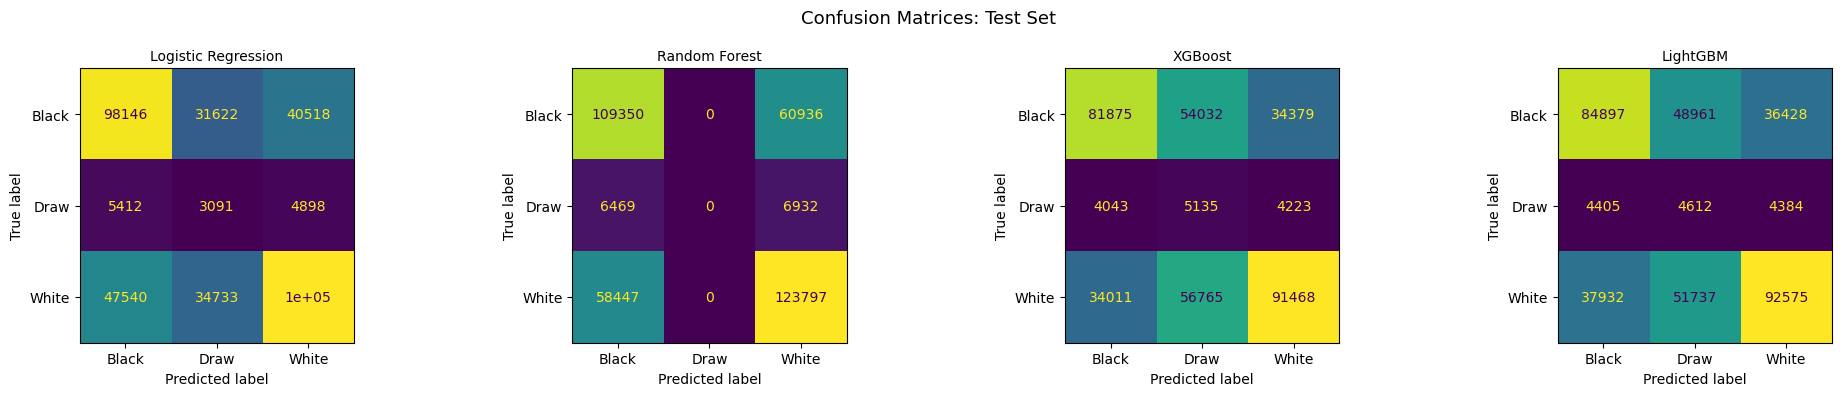

In [28]:
def plot_confusion_matrices(results_map, predicted_store, y_true):
    # One confusion matrix per model, side by side
    try:
        fig, axes = plt.subplots(1, len(results_map), figsize=(5 * len(results_map), 4))
        labels_sorted = sorted(y_true.unique())
        for ax, (name, _) in zip(axes, results_map.items()):
            y_predicted = predicted_store[name]['_pred']
            cm = confusion_matrix(y_true, y_predicted, labels=labels_sorted)
            ConfusionMatrixDisplay(cm, display_labels=labels_sorted).plot(ax=ax, colorbar=False)
            ax.set_title(name, fontsize=10)
        plt.suptitle("Confusion Matrices: Test Set", fontsize=13)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"[confusion-matrices] plot failed: {e}")


plot_confusion_matrices(results, predicted_store, y_test)


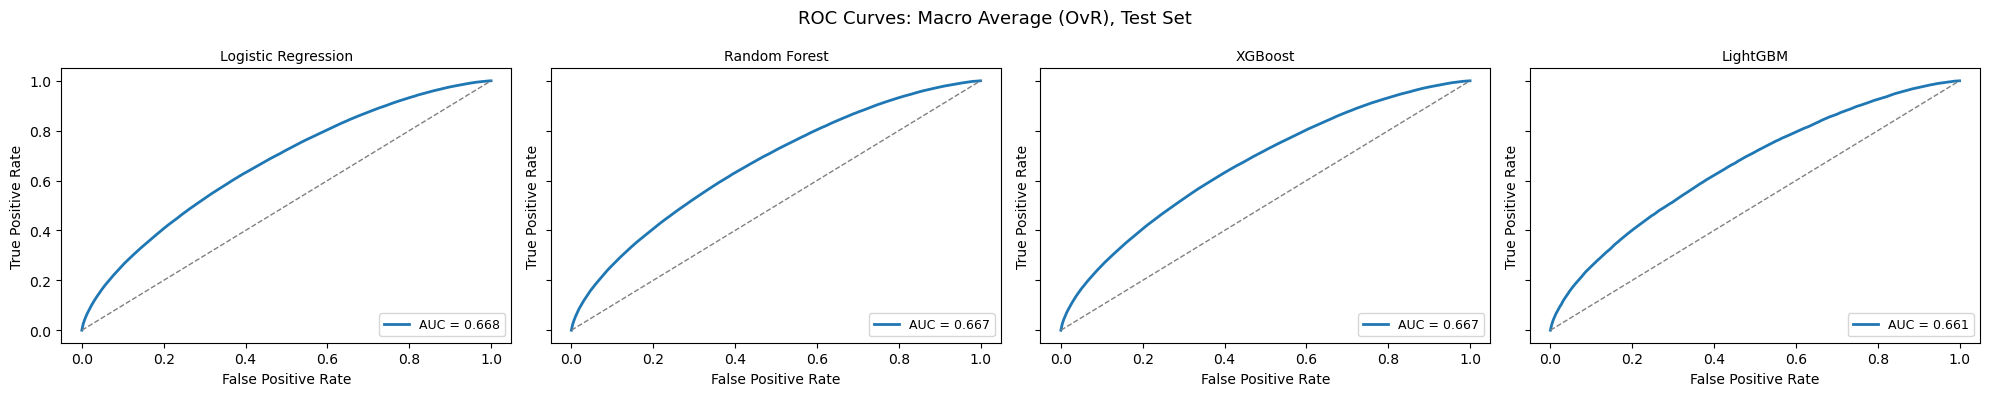

In [29]:
def _mean_roc_curve(y_test_bin, y_probability, classes_sorted):
    # Average per-class ROC curves onto a common FPR grid
    mean_fpr = np.linspace(0, 1, 300)
    tprs = []
    for i, _ in enumerate(classes_sorted):
        fpr, tpr, _thresh = roc_curve(y_test_bin.iloc[:, i], y_probability[:, i])
        tprs.append(np.interp(mean_fpr, fpr, tpr))
    mean_tpr = np.mean(tprs, axis=0)
    return mean_fpr, mean_tpr, auc(mean_fpr, mean_tpr)


def plot_roc_curves(results_map, predicted_store, y_true):
    try:
        classes_sorted = sorted(y_true.unique())
        y_test_bin = pd.get_dummies(y_true, dtype=float)[classes_sorted]
        fig, axes = plt.subplots(1, len(results_map), figsize=(5 * len(results_map), 4), sharey=True)
        for ax, (name, _) in zip(axes, results_map.items()):
            mean_fpr, mean_tpr, auc_val = _mean_roc_curve(
                y_test_bin, predicted_store[name]['_proba'], classes_sorted
            )
            ax.plot(mean_fpr, mean_tpr, lw=2, label=f"AUC = {auc_val:.3f}")
            ax.plot([0, 1], [0, 1], "--", color="grey", lw=1)
            ax.set_xlabel("False Positive Rate")
            ax.set_ylabel("True Positive Rate")
            ax.set_title(name, fontsize=10)
            ax.legend(loc="lower right", fontsize=9)
        plt.suptitle("ROC Curves: Macro Average (OvR), Test Set", fontsize=13)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"[roc] plot failed: {e}")


plot_roc_curves(results, predicted_store, y_test)


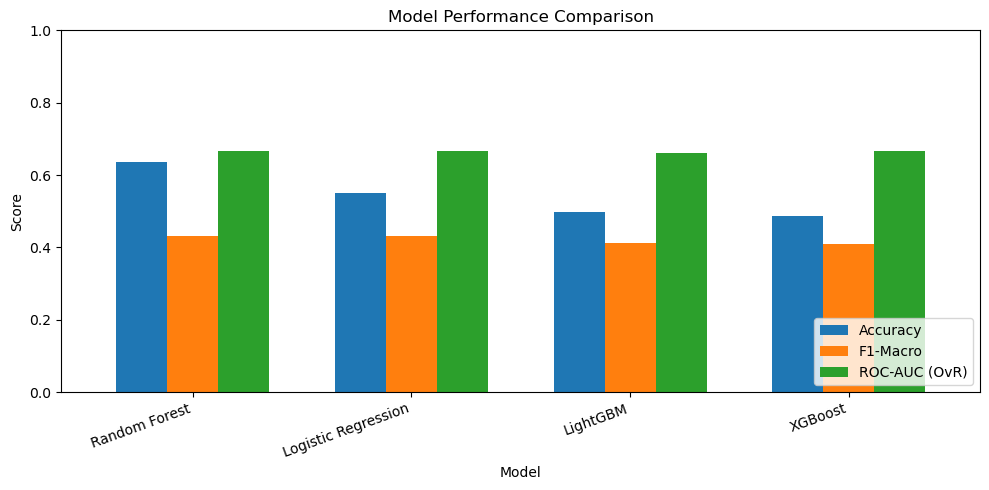

In [30]:
def plot_metric_comparison(compare_df, metrics=('Accuracy', 'F1-Macro', 'ROC-AUC (OvR)')):
    # Grouped bar chart comparing the chosen metrics across models
    try:
        ax = compare_df[list(metrics)].plot(kind='bar', figsize=(10, 5), width=0.7)
        ax.set_title("Model Performance Comparison")
        ax.set_ylabel("Score")
        ax.set_ylim(0, 1)
        ax.legend(loc='lower right')
        plt.xticks(rotation=20, ha='right')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"[metric-comparison] plot failed: {e}")


plot_metric_comparison(compare_df)


In [31]:
def pick_best_model(compare_df, metric='F1-Macro'):
    return compare_df[metric].idxmax()


best_name = pick_best_model(compare_df)
print(best_name)


Random Forest


## Interpretation and Explanation for Supervised Learning

### Feature Engineering
The following features were extracted from the original data:
- EloDiff: difference in elo between white and black (WhiteElo - BlackElo)
- AvgElo: mean elo
- EloRatio: ratio of WhiteElo/BlackElo
- EloDiff_sq: EloDiff^2 to ensure large elo differences are captured as large advantages
- WhiteFavoured: if WhiteElo is higher than BlackElo
- EloProduct: roughly captures the game 'level' (high when both players are strong)
- TC_Base: time control base
- TC_Increment: time control increment
- TC_Total: total time (estimates average of 40 moves per match)
- TC_Category: categorizes game type based on time control
- ECO_Letter: opening letter

Also, WhiteRatingDiff and BlackRatingDiff were excluded as they are considered data leakage; they represent the difference in rating after the game (positive means they won, negative means they lost)
### How were features selected?
Filter method: The correlation coefficient of each feature with the target was found. Higher correlation means that the feature changes with the target more.

Embedded method: Ridge regularisation was used to shrink the coefficients and determine which contribute the most.

### Advanced Supervised Learning
First, the data was split up such that 70% is used to train and the rest to test and evaluate. Next the data was scaled so that the different columns can be compared.

The training data was then split into 5 folds, using 4 of them to train and 1 to validate. Stratified K-Fold cross-validation was the method used to cross-validate.

The following models were then trained:
- Logistic Regression (baseline)
- Random Forest
- XGBoost
- LightGBM

For each of the complex models, hyperparameter tuning was conducted to find the optimal set of hyperparameters for training. Although, since the dataset is very large, they each were trained on a sample of the training set. They were also given a minimal amount of hyperparameter options for the same reason. Otherwise, the process would potentially take hours.

Due to the imbalanced classes, the evaluation metrics used were F1-Macro, F1-Weighted and ROC-AUC. F1-Macro was used to ensure the model performs well under multiclass classification.

Note that class balancing was conducted since previous runs showed that the complex models were completely disregarding the Draw class.

### Results
The following results were obtained on the test set:

| Model               | Accuracy | F1-Macro | F1-Weighted | ROC-AUC (OvR) |
|---------------------|----------|----------|-------------|---------------|
| Random Forest       | 0.6371   | 0.4323   | 0.6252      | 0.6673        |
| Logistic Regression | 0.5470   | 0.4311   | 0.5897      | 0.6677        |
| LightGBM            | 0.4976   | 0.4117   | 0.5606      | 0.6608        |
| XGBoost             | 0.4877   | 0.4098   | 0.5572      | 0.6672        |

All four models performed similarly with Random Forest achieving the highest Accuracy (0.6371) and F1-Macro score (0.4323).

The underperformance of XGBoost and LightGBM can be explained due to the class balancing and small training sample. However, their ROC-AUC scores are still comparable to the others. All of the models achieved ROC-AUC scores of around 0.66-0.67, which is still meaningfully above 0.5 (random guessing).

The difference between F1-Weighted and F1-Macro suggests that the predictability of the Draw class is a weak point. F1-Weighted is increased due to strong performance on White and Black wins, whereas F1-Macro is decreased due to poor performance on the Draw class.

### Limitations
The class imbalance is a large limitation. Due to Draws making up such a small percentage of the data, the models cannot reliably predict draws even when the classes are balanced.

Another limitation is the mere size of the dataset (2.9GB). This limited the performance of the hyperparameter tuning and training since only a sample of the training set was used and a limited amount of hyperparameter options were given in order to keep a reasonable runtime. Ideally, the whole training set would have been used given higher-performing hardware.

Moreover, all the features are based on information available before the game starts. The outcome of a chess game heavily depends on in-game decisions. A player's elo alone cannot measure their full strength and potential.

## Unsupervised Learning

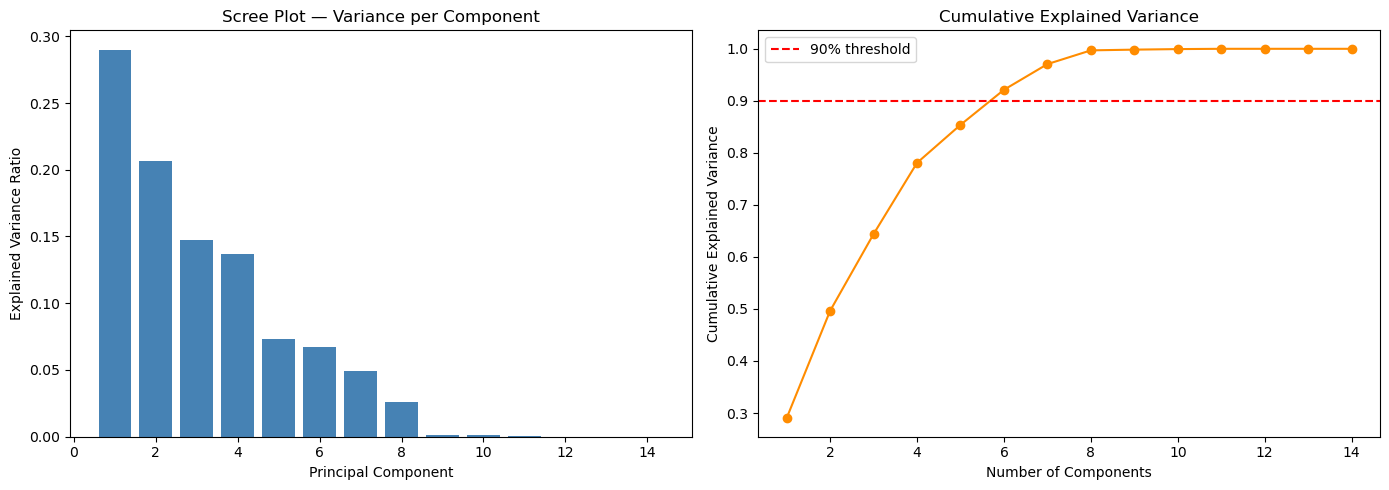


Components needed for ≥90% variance: 6
Cumulative variance with 6 components: 0.9212

Original dimensionality: 14
Reduced dimensionality:  6


In [32]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


def build_unsupervised_splits(model_df, features, y, test_fraction=0.30, random_state=42):
    # Same 70/15/15 stratified split but on the full unsupervised feature set
    X_full = model_df[features]
    X_train_full, X_temp_full, _, y_temp_full = train_test_split(
        X_full, y, test_size=test_fraction, stratify=y, random_state=random_state
    )
    _, X_test_full, _, _ = train_test_split(
        X_temp_full, y_temp_full, test_size=0.50, stratify=y_temp_full, random_state=random_state
    )
    return X_train_full, X_test_full


def scale_train_test(X_train_full, X_test_full):
    scaler = StandardScaler()
    return scaler.fit_transform(X_train_full), scaler.transform(X_test_full), scaler


def plot_pca_variance(exp_var, cum_var):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].bar(range(1, len(exp_var) + 1), exp_var, color='steelblue')
    axes[0].set_xlabel('Principal Component')
    axes[0].set_ylabel('Explained Variance Ratio')
    axes[0].set_title('Scree Plot — Variance per Component')

    axes[1].plot(range(1, len(cum_var) + 1), cum_var, 'o-', color='darkorange')
    axes[1].axhline(y=0.90, color='red', linestyle='--', label='90% threshold')
    axes[1].set_xlabel('Number of Components')
    axes[1].set_ylabel('Cumulative Explained Variance')
    axes[1].set_title('Cumulative Explained Variance')
    axes[1].legend()
    plt.tight_layout()
    plt.show()


def choose_n_components(cum_var, target=0.90):
    return int(np.argmax(cum_var >= target) + 1)


def fit_pca(X_train_sc, X_test_sc, n_components, random_state=42):
    # Reduce to the chosen number of components
    try:
        pca = PCA(n_components=n_components, random_state=random_state)
        return pca.fit_transform(X_train_sc), pca.transform(X_test_sc), pca
    except Exception as e:
        raise RuntimeError(f"PCA fit failed: {e}") from e


X_train_full, X_test_full = build_unsupervised_splits(model_df, FEATURES, y)
X_train_full_sc, X_test_full_sc, scaler_full = scale_train_test(X_train_full, X_test_full)

pca_full = PCA(random_state=42)
pca_full.fit(X_train_full_sc)
exp_var = pca_full.explained_variance_ratio_
cum_var = np.cumsum(exp_var)
plot_pca_variance(exp_var, cum_var)

n_components = choose_n_components(cum_var)
print(f"\nComponents needed for ≥90% variance: {n_components}")
print(f"Cumulative variance with {n_components} components: {cum_var[n_components-1]:.4f}")

X_train_pca, X_test_pca, pca = fit_pca(X_train_full_sc, X_test_full_sc, n_components)
print(f"\nOriginal dimensionality: {X_train_full_sc.shape[1]}")
print(f"Reduced dimensionality:  {X_train_pca.shape[1]}")


k=2  inertia=517,461  silhouette=0.2008
k=3  inertia=443,555  silhouette=0.1983
k=4  inertia=395,542  silhouette=0.2014
k=5  inertia=364,366  silhouette=0.2031
k=6  inertia=330,660  silhouette=0.1972
k=7  inertia=306,192  silhouette=0.1836
k=8  inertia=282,462  silhouette=0.1942
k=9  inertia=263,550  silhouette=0.1974
k=10  inertia=245,697  silhouette=0.1975


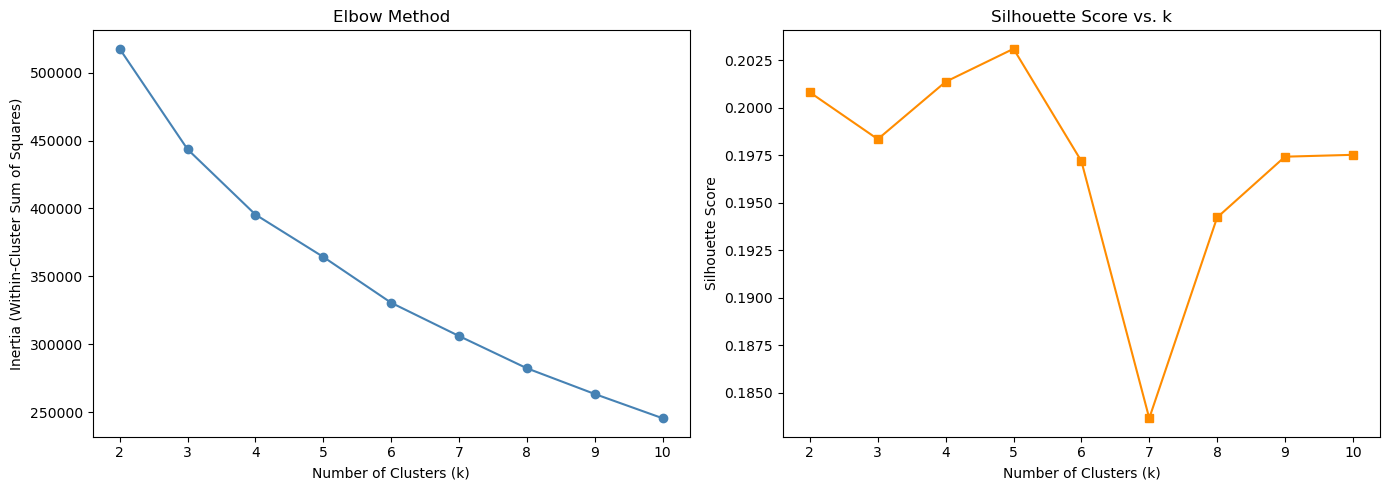


Best k by silhouette score: 5


In [33]:
def subsample_for_search(X, size=50000, random_state=42):
    np.random.seed(random_state)
    idx = np.random.choice(len(X), size=min(size, len(X)), replace=False)
    return X[idx]


def sweep_k(X_sample, k_range=range(2, 11), silhouette_sample=10000, random_state=42):
    # Fit KMeans at each k, logging inertia and silhouette as we go
    inertias, silhouettes = [], []
    for k in k_range:
        try:
            km = KMeans(n_clusters=k, random_state=random_state, n_init=10)
            labels = km.fit_predict(X_sample)
            sil = silhouette_score(X_sample, labels, sample_size=silhouette_sample, random_state=random_state)
        except Exception as e:
            print(f"[k-sweep] k={k} failed: {e}")
            inertias.append(np.nan)
            silhouettes.append(np.nan)
            continue
        inertias.append(km.inertia_)
        silhouettes.append(sil)
        print(f"k={k}  inertia={km.inertia_:,.0f}  silhouette={sil:.4f}")
    return inertias, silhouettes


def plot_k_selection(k_range, inertias, silhouettes):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(list(k_range), inertias, 'o-', color='steelblue')
    axes[0].set_xlabel('Number of Clusters (k)')
    axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)')
    axes[0].set_title('Elbow Method')

    axes[1].plot(list(k_range), silhouettes, 's-', color='darkorange')
    axes[1].set_xlabel('Number of Clusters (k)')
    axes[1].set_ylabel('Silhouette Score')
    axes[1].set_title('Silhouette Score vs. k')
    plt.tight_layout()
    plt.show()


X_sample = subsample_for_search(X_train_pca)
K_range = range(2, 11)
inertias, silhouettes = sweep_k(X_sample, K_range)
plot_k_selection(K_range, inertias, silhouettes)

best_k = list(K_range)[int(np.argmax(silhouettes))]
print(f"\nBest k by silhouette score: {best_k}")


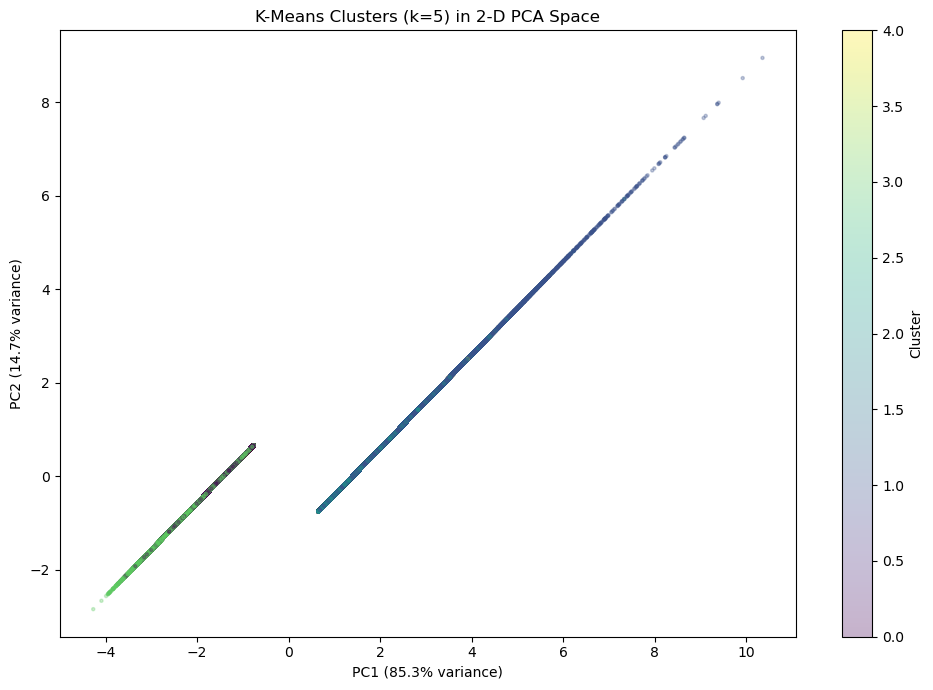

Cluster sizes:
0    393718
1    463061
2    394872
3    453851
4      2176
Name: count, dtype: int64


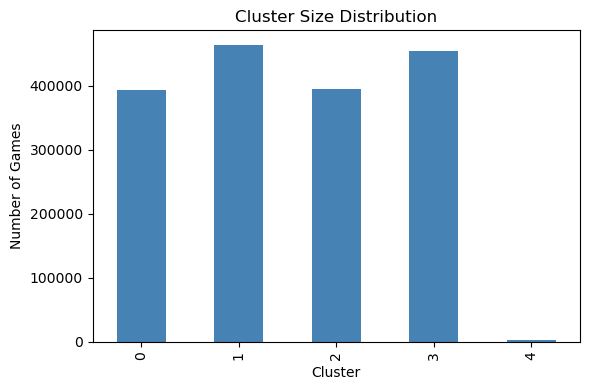

In [34]:
def fit_final_kmeans(X_train_pca, X_test_pca, k, random_state=42):
    # Fit on the full PCA training data at the chosen k
    try:
        km = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        return km, km.fit_predict(X_train_pca), km.predict(X_test_pca)
    except Exception as e:
        raise RuntimeError(f"Final KMeans fit failed: {e}") from e


def project_to_2d(X_train_sc, random_state=42):
    pca_2d = PCA(n_components=2, random_state=random_state)
    return pca_2d.fit_transform(X_train_sc), pca_2d


def plot_clusters_2d(X_vis, labels, pca_2d, k):
    fig, ax = plt.subplots(figsize=(10, 7))
    scatter = ax.scatter(X_vis[:, 0], X_vis[:, 1], c=labels, cmap='viridis', alpha=0.3, s=5)
    plt.colorbar(scatter, ax=ax, label='Cluster')
    ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)")
    ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)")
    ax.set_title(f"K-Means Clusters (k={k}) in 2-D PCA Space")
    plt.tight_layout()
    plt.show()


def plot_cluster_sizes(labels):
    counts = pd.Series(labels).value_counts().sort_index()
    print("Cluster sizes:")
    print(counts)
    plt.figure(figsize=(6, 4))
    counts.plot(kind='bar', color='steelblue')
    plt.xlabel('Cluster')
    plt.ylabel('Number of Games')
    plt.title('Cluster Size Distribution')
    plt.tight_layout()
    plt.show()


kmeans, train_clusters, test_clusters = fit_final_kmeans(X_train_pca, X_test_pca, best_k)
X_vis, pca_2d = project_to_2d(X_train_sc)
plot_clusters_2d(X_vis, train_clusters, pca_2d, best_k)
plot_cluster_sizes(train_clusters)


In [35]:
def report_silhouette(X_train_pca, train_clusters, X_test_pca, test_clusters,
                      sample_size=10000, random_state=42):
    # Silhouette on train and test; same sampling strategy as the sweep
    try:
        sil_train = silhouette_score(X_train_pca, train_clusters, sample_size=sample_size, random_state=random_state)
        sil_test  = silhouette_score(X_test_pca,  test_clusters,  sample_size=sample_size, random_state=random_state)
    except Exception as e:
        raise RuntimeError(f"Silhouette evaluation failed: {e}") from e

    print(f"{'Metric':<25} {'Train':>10} {'Test':>10}")
    print("-" * 47)
    print(f"{'Silhouette Score':<25} {sil_train:>10.4f} {sil_test:>10.4f}")
    print()
    print("Silhouette Score: ranges from -1 to 1; higher is better.")
    print("  > 0.5 = strong cluster structure")
    print("  0.25–0.5 = reasonable structure")
    print("  < 0.25 = weak or overlapping clusters")
    return sil_train, sil_test


_ = report_silhouette(X_train_pca, train_clusters, X_test_pca, test_clusters)


Metric                         Train       Test
-----------------------------------------------
Silhouette Score              0.1770     0.1757

Silhouette Score: ranges from -1 to 1; higher is better.
  > 0.5 = strong cluster structure
  0.25–0.5 = reasonable structure
  < 0.25 = weak or overlapping clusters


=== Cluster Profiles (mean feature values) ===

Cluster                     0         1         2         3         4
WhiteElo               1884.1    1629.3    2029.3    1469.6    1453.0
BlackElo               2033.8    1464.2    1884.1    1625.2    1440.7
EloDiff                -149.8     165.1     145.2    -155.5      12.3
AvgElo                 1958.9    1546.8    1956.7    1547.4    1446.9
EloRatio                  0.9       1.1       1.1       0.9       1.0
EloDiff_sq            42642.3   50323.6   39539.9   45414.6   52293.1
WhiteFavoured             0.0       1.0       1.0       0.0       0.5
EloProduct          3854767.9 2405524.1 3847072.6 2408504.4 2123097.5
TC_Base                 193.1     391.0     194.9     389.2    8111.9
TC_Increment              0.6       1.9       0.7       1.9      64.7
TC_Total                218.7     466.8     221.1     464.1   10699.8
TC_Category_encoded       1.2       1.1       1.2       1.1       2.0
ECO_Letter_encoded        2.1       2.6   

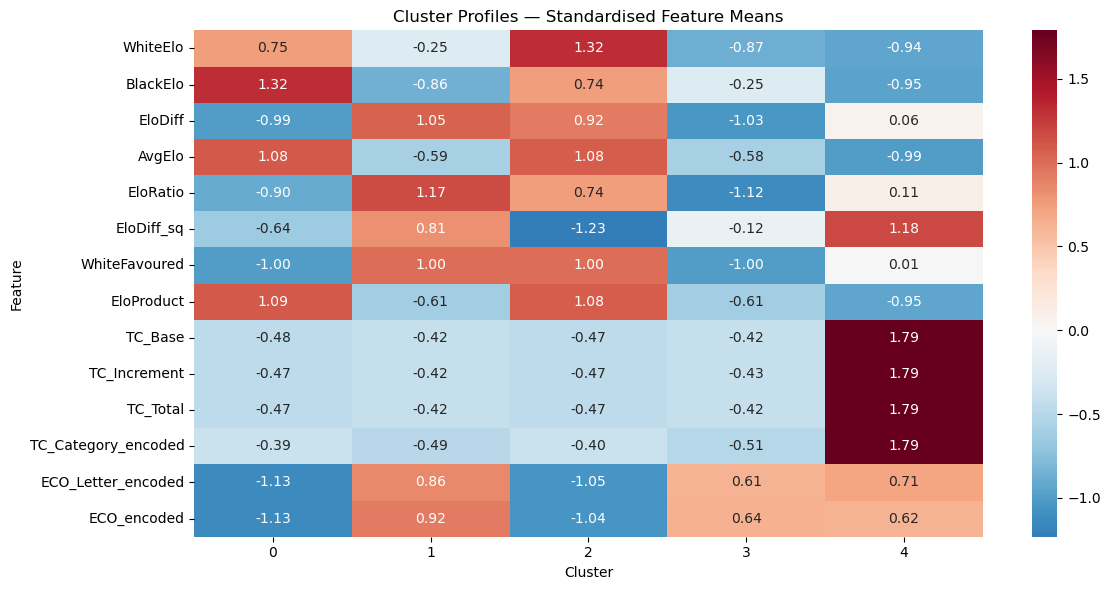

In [36]:
def build_cluster_profiles(X_train_full, labels):
    # Mean feature values per cluster
    df = X_train_full.copy()
    df['Cluster'] = labels
    return df.groupby('Cluster').mean()


def standardise_profiles(profiles):
    return (profiles - profiles.mean()) / profiles.std()


def plot_cluster_profiles(profiles_std):
    plt.figure(figsize=(12, 6))
    sns.heatmap(profiles_std.T, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
    plt.title('Cluster Profiles — Standardised Feature Means')
    plt.xlabel('Cluster')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()


cluster_profiles = build_cluster_profiles(X_train_full, train_clusters)
print("=== Cluster Profiles (mean feature values) ===\n")
print(cluster_profiles.T.to_string(float_format='{:.1f}'.format))
plot_cluster_profiles(standardise_profiles(cluster_profiles))


### Justification of PCA + K-Means

#### Why PCA?
- Our feature list consists of variables that are highly correlated (for instance, WhiteElo and BlackElo together create AvgElo, EloProduct, EloRatio). Multicollinearity is solved by PCA via orthogonalization.
- More than 90% of variance was retained with PCA.
- As opposed to feature selection, PCA preserves all data of interest, which is critical because there is no way of knowing beforehand which features are responsible for difficulty levels.

#### Why K-Means?
- Our goal is to see whether the data partitions into natural groups based on difficulty levels, which implies the need for partitioning algorithms, such as K-Means.
- It's a pretty large dataset and compared to other clustering algorithms, K-Means is computationally cheap and more suitable for our purposes.
- Features that we consider (elo ratings, time controls, and opening code) are numerical and approximately spherical in PCA-transformed space, meaning that they fit K-Means assumptions about cluster shapes.
- The elbow criterion and silhouette score provide an objective method of choosing k without specifying difficulty tiers beforehand.

#### Limitations:
- PCA is a linear method; non-linear relationships between features don't work. However, the engineered features (EloDiff_sq, EloProduct) already capture key non-linearities.
- The cluster labels are unsupervised and require domain interpretation to confirm they align with meaningful difficulty tiers.

### Interpretation of Unsupervised Learning

Clustering was done in the more than 90% variance PCA space. The 2-D projection shown on the plot is for visualisation only. We swept k from 2 to 10 and the silhouette score peaked at k=5, so the final model splits the games into 5 clusters with the following mean feature profiles:

| Cluster | AvgElo | EloDiff | Typical TC_Total (s) | Interpretation                                                                 |
|---------|--------|---------|----------------------|--------------------------------------------------------------------------------|
| 0       | 1958.9 | -149.8  | ~219                 | Higher-rated blitz/rapid games where Black is the stronger player              |
| 1       | 1546.8 |  165.1  | ~467                 | Mid/low-rated games where White is the stronger player                         |
| 2       | 1956.7 |  145.2  | ~221                 | Higher-rated blitz/rapid games where White is the stronger player              |
| 3       | 1547.4 | -155.5  | ~464                 | Mid/low-rated games where Black is the stronger player                         |
| 4       | 1446.9 |   12.3  | ~10,700              | Low-rated classical games, with an evenly matched pair and very long time controls |

Unlike the earlier 2-cluster run that just split on player strength, the 5-cluster solution organises games along three axes: overall Elo level (high ~1960 vs mid/low ~1450–1550), the sign of EloDiff (who is favoured), and time control (cluster 4 is cleanly separated by classical-length games). Clusters 0/2 and 1/3 form mirrored pairs where everything except the direction of the Elo imbalance is similar, which is reassuring because it's exactly the symmetry we'd expect from the engineered features.

Cluster quality is still weak, though. The silhouette scores are train: 0.1770, test: 0.1757, both below the 0.25 threshold for "reasonable structure". This matches what we already saw in stage 1: the chess data is quite homogeneous, so even after the PCA fix the algorithm is mostly carving up a continuous distribution rather than finding truly separated groups. The test score tracking the train score closely does at least show the partition is stable out-of-sample.

In conclusion, the unsupervised learning shows that player rating, rating imbalance, and time control are the primary factors differentiating chess games, but games don't fall into clean "difficulty tiers" instead they form a smooth gradient that K-Means is dividing somewhat arbitrarily.

## Ethical Considerations
### Bias and Fairness
This dataset is based off of Lichess players (an online chess platform). Therefore, the dataset is not necessarily representative of all chess players globally, regardless of it being one of the largest chess platforms. The models trained on the data may not translate well to chess being played on a physical board, or even other online platforms.

Also, the elo rating system itself introduces some kind of bias. New Lichess players are assigned a temporary rating that might not accurately reflect their skill level, and players who do not play frequently may have outdated ratings.

### Privacy
The dataset used contains game information like results, ratings, time control, and openings, but does not contain any personal user information. Although usernames are publicly visible on Lichess, they were not used in any capacity for this project. Therefore, privacy considerations for this project are minimal.

### Limitations and Future Work
The biggest limitation is that all features were engineered using pre-game information. The outcome of a game of chess is mainly determined by the moves made during the game rather than pre-game stats. Future work could include in-game features such as move quality scores.

Another significant limitation is the size of the dataset compared to the computational power of our devices. Since the dataset was very large, hyperparamater tuning and training took very long (potentially 1+ hours). To combat this, only a sample of the training data was used. Although the sample still contained a large amount of data, the models were not trained to their full potential. Access to greater computational resources would allow us to use the full dataset for training and conduct a broader hyperparameter search.